In [177]:
import mujoco
import mediapy
import numpy as np

from typing import Callable

In [36]:
model = mujoco.MjModel.from_xml_path("../robot_models/cart_pole/scene.xml")
data = mujoco.MjData(model)

# avoid rendeder to be black-screened
try:
    renderer
except:
    renderer = mujoco.Renderer(model)

""

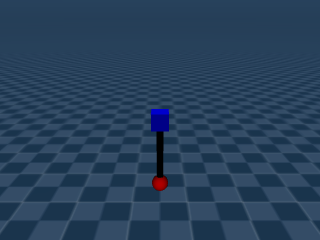

In [37]:
mujoco.mj_step(model, data)
renderer.update_scene(data)

mediapy.show_image(renderer.render())

In [38]:
import datetime

target_path = (
    f"../data/raw/cart_pole/{datetime.datetime.now().strftime('%Y%m%d%H%M%S%f')}.csv"
)

In [190]:
def get_desc(
    amps: np.ndarray,
    freqs: np.ndarray,
    is_sin: np.ndarray,
    amp_decimal: int,
    freq_decimal: int,
) -> str:
    atoms = []
    for i, (is_sin_now, freq, amp) in enumerate(zip(is_sin, freqs, amps)):
        func = "sin" if is_sin_now else "cos"
        amp = np.round(amp, amp_decimal)
        freq = np.round(freq, freq_decimal)
        if i == 0 and amp <= 0:
            atoms.append("-")
        if i > 0:
            atoms.append(" + " if amp >= 0 else " - ")
        atoms.append(f"{np.abs(amp)} * {func}({freq} * t)")
    return "".join(atoms)


def gen_ctrl(
    length: int,
    max_amp: float = 0.25,
    max_freq: float = 1,
    amp_decimal: int = 3,
    freq_decimal: int = 2,
) -> tuple[Callable[[float], float], str]:
    amps = np.round((np.random.rand(length) - 0.5) * max_amp * amp_decimal, decimals=3)
    freqs = np.round((np.random.rand(length) - 0.5) * max_freq * freq_decimal, decimals=2)
    is_sin = np.random.randint(0, 2, size=length)

    def _ctrl(_t: float) -> float:
        res = 0.0
        for is_sin_now, freq, amp in zip(is_sin, freqs, amps):
            res += (amp * np.sin(freq * _t)) if is_sin_now else (amp * np.cos(freq * _t))
        return res

    return _ctrl, get_desc(amps, freqs, is_sin, amp_decimal, freq_decimal)


np.random.seed(77)
ctrl_1, ctrl_1_desc = gen_ctrl(5, max_amp=0.1)
ctrl_2, ctrl_2_desc = gen_ctrl(5)

print("ctrl_1 =", ctrl_1_desc)
print("ctrl_2 =", ctrl_2_desc)

ctrl_1 = 0.126 * sin(0.58 * t) + 0.043 * sin(-0.35 * t) + 0.076 * cos(0.08 * t) - 0.108 * sin(-0.52 * t) - 0.124 * cos(0.09 * t)
ctrl_2 = 0.191 * sin(0.44 * t) + 0.318 * sin(-0.36 * t) + 0.166 * sin(0.72 * t) + 0.351 * sin(0.92 * t) - 0.329 * cos(0.96 * t)


In [193]:
from recorder import Recorder

duration = 10  # (seconds)
framerate = 30  # (Hz)

rec = Recorder(model)

from math import ceil

n_steps = int(ceil(duration * framerate)) + 1

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
import numpy as np


def bound_1(q: float, v: float):
    return -0.9 * q - 0.01 * v


def bound_2(q: float, v: float):
    return -0.15 * q - 0.02 * v


while data.time < duration:
    t = data.time
    q1, q2 = data.qpos
    v1, v2 = data.qvel
    data.ctrl[0] = ctrl_1(t) + bound_1(q1, v1)
    data.ctrl[1] = ctrl_2(t) + bound_2(q2, v2)
    mujoco.mj_step(model, data)

    # record data
    rec.record(data)

    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

rec.save_df(target_path)

mediapy.show_video(frames, fps=framerate)

This browser does not support the video tag.


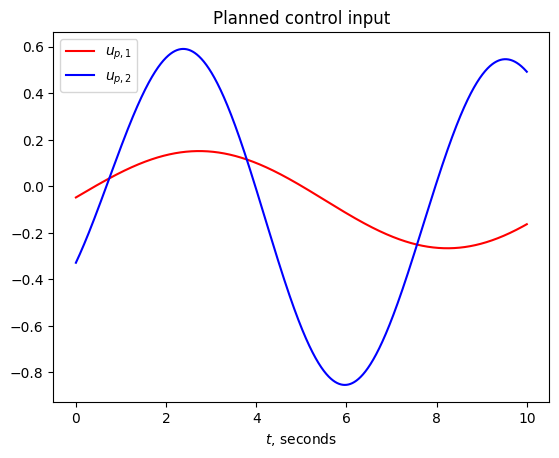

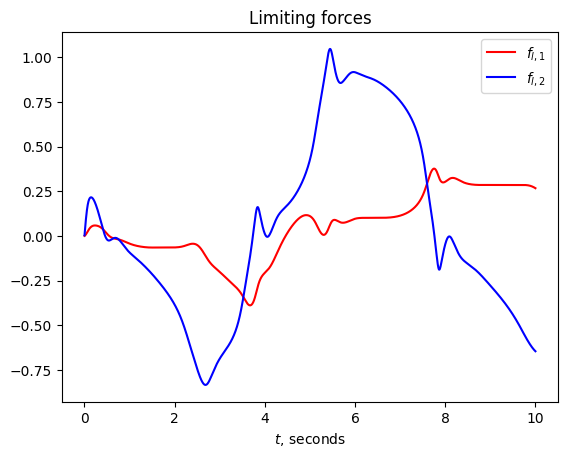

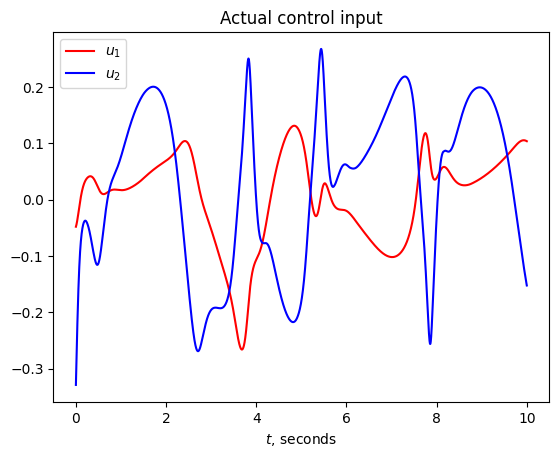

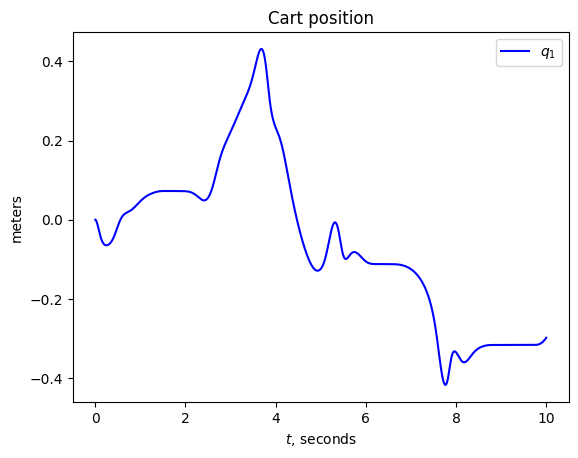

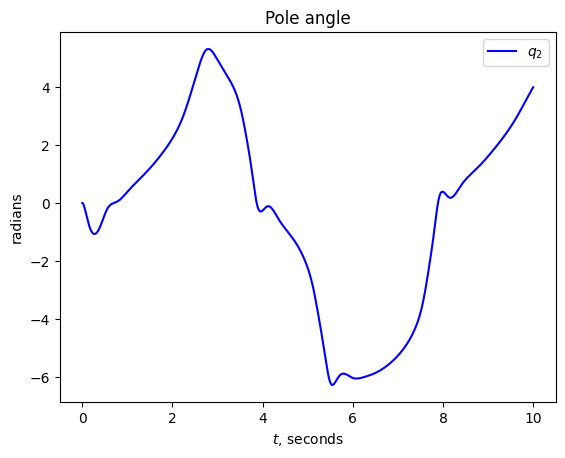

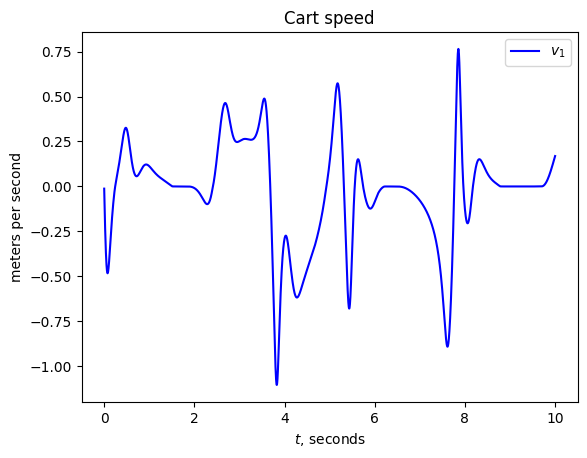

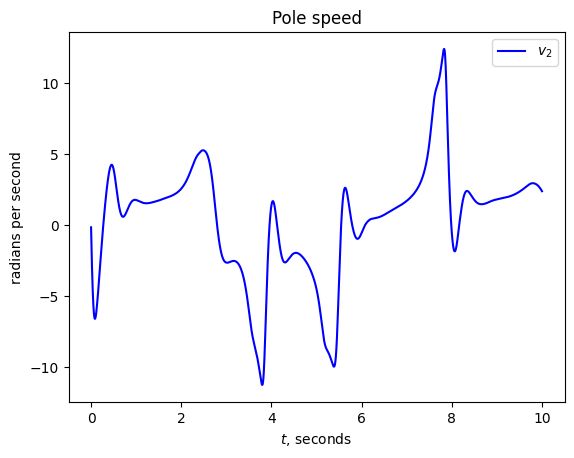

In [217]:
import matplotlib.pyplot as plt

timespan = np.array(rec.history["time"])
ctrls = np.array(rec.history["ctrl"])
q_poses = np.array(rec.history["qpos"])
q_vels = np.array(rec.history["qvel"])

plt.title("Planned control input")
plt.plot(timespan, ctrl_1(timespan), color="red", label="$u_{p, 1}$")
plt.plot(timespan, ctrl_2(timespan), color="blue", label="$u_{p, 2}$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Limiting forces")
plt.plot(timespan, bound_1(q_poses[:, 0], q_vels[:, 0]), color="red", label="$f_{l, 1}$")
plt.plot(timespan, bound_2(q_poses[:, 1], q_vels[:, 1]), color="blue", label="$f_{l, 2}$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Actual control input")
plt.plot(timespan, ctrls[:, 0], color="red", label="$u_1$")
plt.plot(timespan, ctrls[:, 1], color="blue", label="$u_2$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Cart position")
plt.plot(timespan, q_poses[:, 0], color="blue", label="$q_1$")
plt.legend(loc="best")
plt.ylabel("meters")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Pole angle")
plt.plot(timespan, q_poses[:, 1], color="blue", label="$q_2$")
plt.legend(loc="best")
plt.ylabel("radians")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Cart speed")
plt.plot(timespan, q_vels[:, 0], color="blue", label="$v_1$")
plt.legend(loc="best")
plt.ylabel("meters per second")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Pole speed")
plt.plot(timespan, q_vels[:, 1], color="blue", label="$v_2$")
plt.legend(loc="best")
plt.ylabel("radians per second")
plt.xlabel("$t$, seconds")
plt.show()